In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Task 1 & 2: Load the data from different formats
df_csv = pd.read_csv("C:\\Users\\landg\\Downloads\\Sales_Data.csv")
df_excel = pd.read_excel("C:\\Users\\landg\\Downloads\\Sales_Data.xlsx")
df_json = pd.read_json("C:\\Users\\landg\\Downloads\\Sales_Data.json")

In [3]:
# Task 3: Explore structure
print("CSV Data:\n", df_csv.head())
print("\nData Types:\n", df_csv.dtypes)
print("\nMissing Values:\n", df_csv.isnull().sum())

CSV Data:
    Order_ID Customer     Product     Category  Quantity  Price_per_unit  \
0      1001    Alice      Laptop  Electronics         1            1200   
1      1002      Bob  Smartphone  Electronics         2             800   
2      1003  Charlie      Tablet  Electronics         1             300   
3      1004    David      Laptop  Electronics         1            1200   
4      1005      Eve  Smartwatch  Accessories         3             200   

   Total_Sales  
0         1200  
1         1600  
2          300  
3         1200  
4          600  

Data Types:
 Order_ID           int64
Customer          object
Product           object
Category          object
Quantity           int64
Price_per_unit     int64
Total_Sales        int64
dtype: object

Missing Values:
 Order_ID          0
Customer          0
Product           0
Category          0
Quantity          0
Price_per_unit    0
Total_Sales       0
dtype: int64


In [4]:
# Task 4: Data Cleaning
df_csv.drop_duplicates(inplace=True)
df_csv.fillna({"Quantity": 0, "Price_per_unit": df_csv["Price_per_unit"].mean()}, inplace=True)

In [5]:
# Task 5: Unified format (all files are similar here, so we use CSV version as standard)
df = df_csv.copy()


In [6]:
# Task 6: Data Transformation
# Deriving a new column (if not already there)
df["Total_Sales"] = df["Quantity"] * df["Price_per_unit"]

In [7]:
# Task 7: Descriptive statistics
print("\nDescriptive Stats:\n", df.describe())
print("\nTotal Sales by Category:\n", df.groupby("Category")["Total_Sales"].sum())
print("\nAverage Order Value:\n", df["Total_Sales"].mean())


Descriptive Stats:
           Order_ID  Quantity  Price_per_unit  Total_Sales
count     5.000000  5.000000        5.000000     5.000000
mean   1003.000000  1.600000      740.000000   980.000000
std       1.581139  0.894427      477.493455   521.536192
min    1001.000000  1.000000      200.000000   300.000000
25%    1002.000000  1.000000      300.000000   600.000000
50%    1003.000000  1.000000      800.000000  1200.000000
75%    1004.000000  2.000000     1200.000000  1200.000000
max    1005.000000  3.000000     1200.000000  1600.000000

Total Sales by Category:
 Category
Accessories     600
Electronics    4300
Name: Total_Sales, dtype: int64

Average Order Value:
 980.0


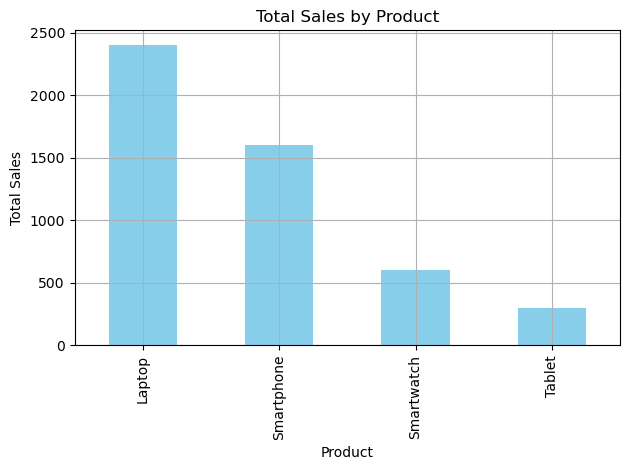

In [8]:
# Task 8: Visualizations
# Bar Plot - Total Sales by Product
df.groupby("Product")["Total_Sales"].sum().plot(kind="bar", title="Total Sales by Product", ylabel="Total Sales", xlabel="Product", color="skyblue")
plt.grid(True)
plt.tight_layout()
plt.show()


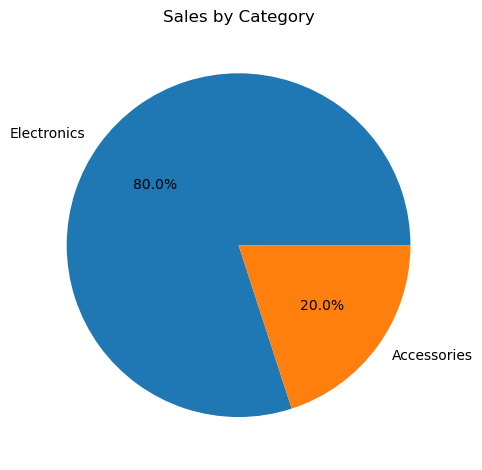

In [9]:
# Pie Chart - Category Distribution
df["Category"].value_counts().plot(kind="pie", autopct='%1.1f%%', title="Sales by Category")
plt.ylabel('')
plt.tight_layout()
plt.show()

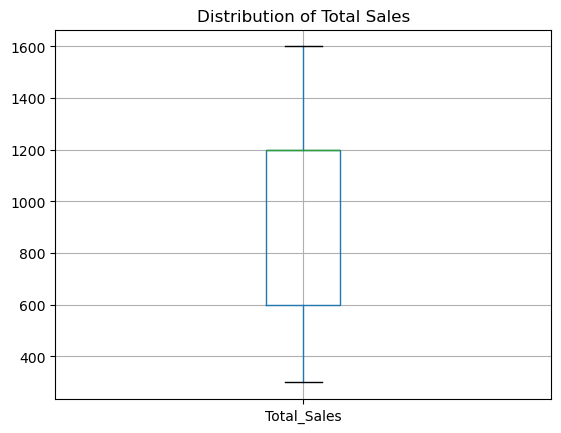

In [10]:
# Box Plot - Distribution of Total Sales
df.boxplot(column="Total_Sales")
plt.title("Distribution of Total Sales")
plt.grid(True)
plt.show()